# K-Means Clustering

## 0. Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

import torch

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("UMAP not installed, using PCA")

## 1. Configuration

In [ ]:
ACTS_DIR = Path("acts/llama-2-7b/facts_variations")
CSV_PATH = Path("datasets/facts_variations.csv")

PROBE_LAYERS = None # can take list or None
POOLING = "mean" # "mean" or "last"
K_OVERRIDE  = None # None = set to number of unique original statements

KMEANS_SEED = 42
RANDOM_SEED  = 42
PROJ_METHOD  = "umap" if HAS_UMAP else "pca"
np.random.seed(RANDOM_SEED)

## 2. Get layers & files

In [ ]:
assert ACTS_DIR.exists(), f"Activations directory not found: {ACTS_DIR}"

# Parse filenames
pattern = re.compile(r"^layer_(\d+)_(\d+)\.pt$")
found = {}

for p in sorted(ACTS_DIR.iterdir()):
    m = pattern.match(p.name)
    if m:
        layer, row = int(m.group(1)), int(m.group(2))
        found.setdefault(layer, {})[row] = p

all_layers = sorted(found.keys())
print(f"Found {len(all_layers)} layer(s): {all_layers}")
print(f"Files per layer: { {l: len(found[l]) for l in all_layers} }")

# Apply PROBE_LAYERS filter
if PROBE_LAYERS is not None:
    missing = [l for l in PROBE_LAYERS if l not in found]
    if missing:
        print(f"WARNING: requested layers not found and will be skipped: {missing}")
    probe_layers = [l for l in PROBE_LAYERS if l in found]
else:
    probe_layers = all_layers

print(f"Probing layers: {probe_layers}")

Found 7 layer(s): [8, 10, 12, 14, 16, 18, 20]
Files per layer: {8: 550, 10: 550, 12: 550, 14: 550, 16: 550, 18: 550, 20: 550}
Probing layers: [8, 10, 12, 14, 16, 18, 20]


## 3. Load CSV and build ground-truth labels

In [ ]:
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

assert "variation" in df.columns, "Expected a 'variation' column"
assert "label"     in df.columns, "Expected a 'label' column"

df["label"] = df["label"].astype(int)

# Add group id
orig_col = "original_statement" if "original_statement" in df.columns else "variation"
originals = df[orig_col].fillna(df["variation"])
unique_originals = originals.unique()
orig2id = {o: i for i, o in enumerate(unique_originals)}
id2stmt  = {i: (o[:55] + "..." if len(o) > 55 else o) for o, i in orig2id.items()}
df["group_id"] = originals.map(orig2id)

n_rows        = len(df)
true_labels   = df["group_id"].tolist()
binary_labels = df["label"].tolist()
K = K_OVERRIDE if K_OVERRIDE else len(unique_originals)

print(f"CSV rows: {n_rows}  |  unique originals: {len(unique_originals)}  |  K={K}")
print(f"Label balance: {df['label'].value_counts().to_dict()}")

for layer in probe_layers:
    n_files = len(found[layer])
    if n_files != n_rows:
        print(f"WARNING layer {layer}: {n_files} .pt files but {n_rows} CSV rows")

df.head()

CSV rows: 550  |  unique originals: 50  |  K=50
Label balance: {0: 319, 1: 231}


,variation,label,original_statement,variation_index,group_id
0,The Milky Way is a spiral galaxy.,1,The Milky Way is a spiral galaxy.,0,0
1,A spiral galaxy is what the Milky Way is.,1,The Milky Way is a spiral galaxy.,1,0
2,It is the Milky Way that constitutes a spiral ...,1,The Milky Way is a spiral galaxy.,2,0
3,There exists a spiral galaxy known as the Milk...,1,The Milky Way is a spiral galaxy.,3,0
4,"The Milky Way, our home galaxy, has a spiral s...",1,The Milky Way is a spiral galaxy.,4,0


## 4. Load activations from .pt files

In [ ]:
def load_layer_activations(layer, row_files, n_rows, pooling):
    """
    Load all row .pt files for a layer into a (N, hidden_size) float32 array.
    Handles 1-D vectors and 2-D (seq_len, hidden_size) tensors.
    Missing rows are filled with zeros.
    """
    vecs = []
    hidden_size = None

    for row_idx in range(n_rows):
        if row_idx not in row_files:
            vecs.append(None)
            continue

        t = torch.load(row_files[row_idx], map_location="cpu").float()

        if t.dim() == 3:
            t = t.squeeze(0)

        if t.dim() == 1:
            vec = t.numpy()
        elif t.dim() == 2:
            vec = t.mean(dim=0).numpy() if pooling == "mean" else t[-1].numpy()
        else:
            raise ValueError(f"Unexpected tensor shape {t.shape} in {row_files[row_idx]}")

        if hidden_size is None:
            hidden_size = vec.shape[0]
        vecs.append(vec)

    zero = np.zeros(hidden_size, dtype=np.float32)
    vecs = [v if v is not None else zero for v in vecs]
    return np.stack(vecs, axis=0)


activations = {}
for layer in probe_layers:
    print(f"  Loading layer {layer} ...", end=" ")
    activations[layer] = load_layer_activations(layer, found[layer], n_rows, POOLING)
    print(f"shape={activations[layer].shape}")

print("\nAll activations loaded.")

  Loading layer 8 ... shape=(550, 4096)
  Loading layer 10 ... shape=(550, 4096)
  Loading layer 12 ... shape=(550, 4096)
  Loading layer 14 ... shape=(550, 4096)
  Loading layer 16 ... shape=(550, 4096)
  Loading layer 18 ... shape=(550, 4096)
  Loading layer 20 ... shape=(550, 4096)

All activations loaded.


## 5. K-means clustering per layer

In [33]:
def run_kmeans(X, k, seed=KMEANS_SEED):
    X_norm = normalize(X, norm="l2")
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=seed)
    return km.fit_predict(X_norm)


results = {}
for layer in probe_layers:
    X = activations[layer]
    labels = run_kmeans(X, K)
    ari = adjusted_rand_score(true_labels, labels)
    nmi = normalized_mutual_info_score(true_labels, labels)
    sil = silhouette_score(normalize(X, norm="l2"), labels,
                           sample_size=min(1000, len(X)), random_state=RANDOM_SEED)
    results[layer] = dict(cluster_labels=labels, ari=ari, nmi=nmi, silhouette=sil)
    print(f"Layer {layer:2d}  |  ARI={ari:.4f}  NMI={nmi:.4f}  Silhouette={sil:.4f}")

metrics_df = pd.DataFrame(
    [{"layer": l, "ARI": r["ari"], "NMI": r["nmi"], "Silhouette": r["silhouette"]}
     for l, r in results.items()]
).set_index("layer")

best_layer  = metrics_df["ARI"].idxmax()
worst_layer = metrics_df["ARI"].idxmin()
print(f"\nBest layer (ARI): {best_layer}  |  Worst: {worst_layer}")
metrics_df

Layer  8  |  ARI=0.4933  NMI=0.7972  Silhouette=0.1358
Layer 10  |  ARI=0.4714  NMI=0.7916  Silhouette=0.1511
Layer 12  |  ARI=0.4812  NMI=0.7933  Silhouette=0.1533
Layer 14  |  ARI=0.5004  NMI=0.7993  Silhouette=0.1485
Layer 16  |  ARI=0.5122  NMI=0.8182  Silhouette=0.1583
Layer 18  |  ARI=0.5854  NMI=0.8509  Silhouette=0.1633
Layer 20  |  ARI=0.5336  NMI=0.8312  Silhouette=0.1623

Best layer (ARI): 18  |  Worst: 10


,ARI,NMI,Silhouette
layer,,,
8,0.493342,0.797217,0.135788
10,0.471429,0.791584,0.151088
12,0.481168,0.793307,0.153308
14,0.500380,0.799314,0.148546
16,0.512230,0.818196,0.158250
18,0.585359,0.850900,0.163293
20,0.533599,0.831161,0.162313


### Metric reference
| Metric | Perfect | Meaning |
|--------|---------|--------|
| **ARI** | 1.0 | Clusters match original-statement groups exactly |
| **NMI** | 1.0 | Same intuition, robust to cluster-size imbalance |
| **Silhouette** | 1.0 | Points are compact within clusters, well-separated between them |

## 6. 2-D projection (UMAP / PCA)

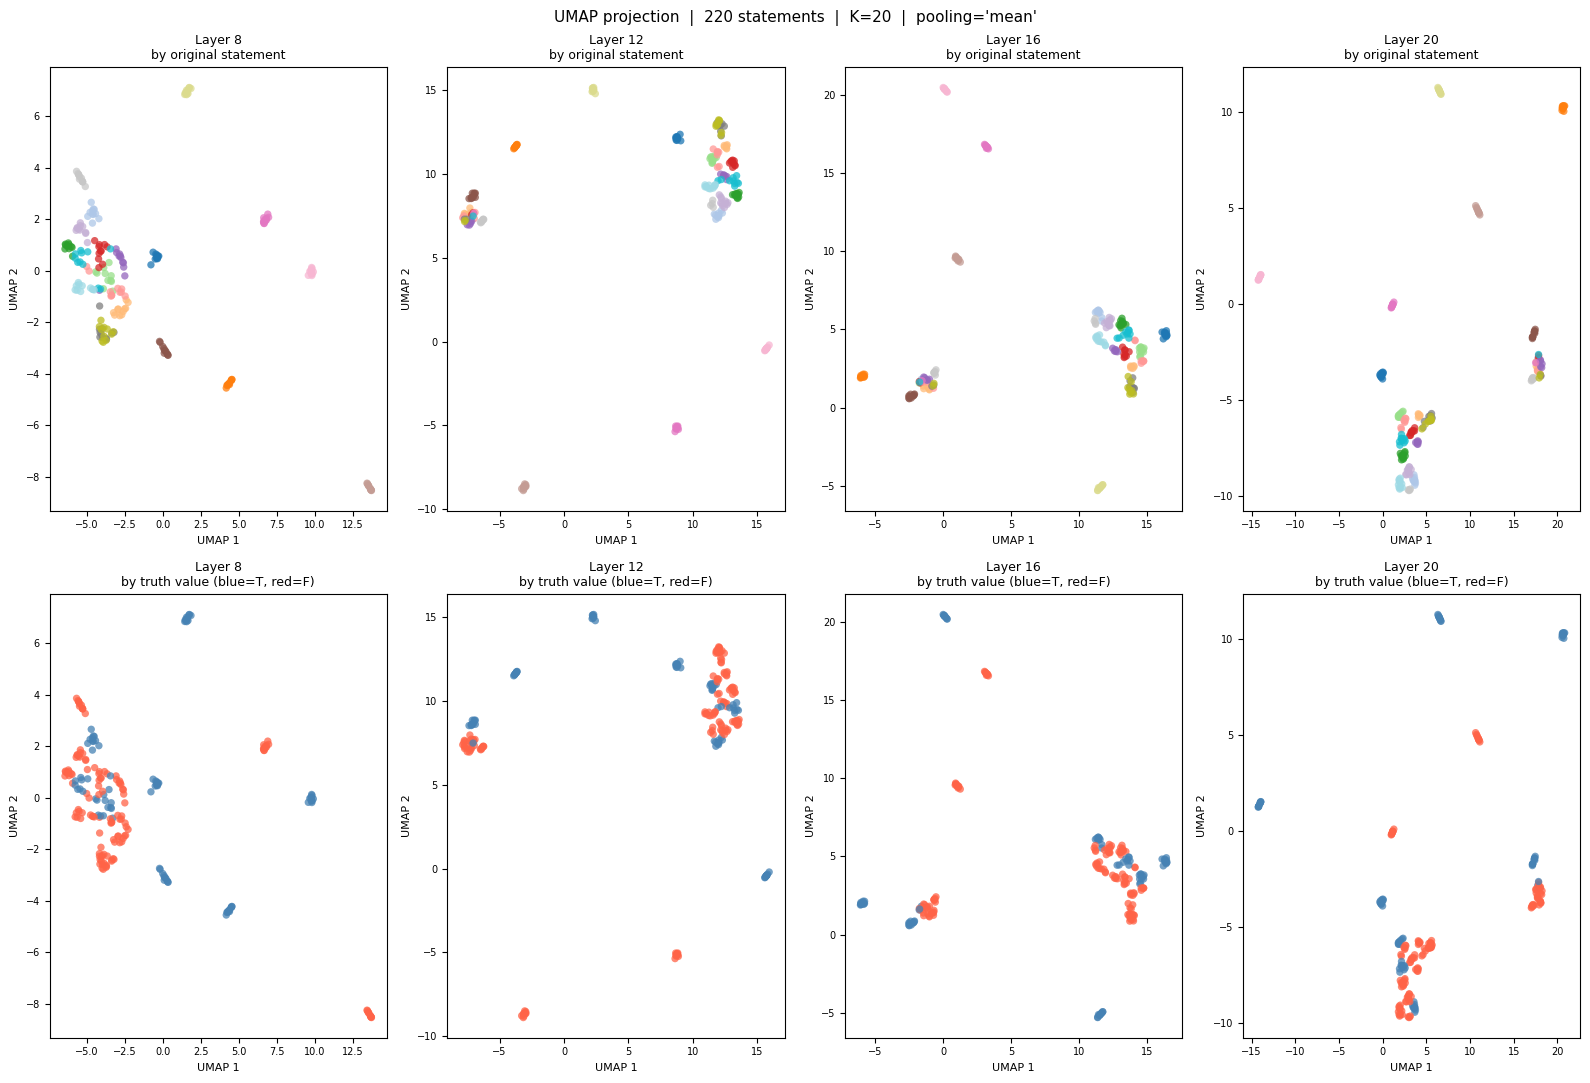

In [28]:
def project_2d(X):
    X_norm = normalize(X, norm="l2")
    if PROJ_METHOD == "umap":
        return umap.UMAP(n_components=2, random_state=RANDOM_SEED, metric="cosine").fit_transform(X_norm)
    return PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_norm)


palette       = cm.get_cmap("tab20", len(unique_originals))
group_colours = np.array([palette(g) for g in true_labels])
truth_colours = np.where(np.array(binary_labels) == 1, "steelblue", "tomato")

n = len(probe_layers)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 11))
if n == 1:
    axes = axes.reshape(2, 1)

for col, layer in enumerate(probe_layers):
    coords = project_2d(activations[layer])

    axes[0, col].scatter(coords[:, 0], coords[:, 1], c=group_colours, s=28, alpha=0.75, linewidths=0)
    axes[0, col].set_title(f"Layer {layer}\nby original statement", fontsize=9)
    axes[0, col].set_xlabel("UMAP 1", fontsize=8)
    axes[0, col].set_ylabel("UMAP 2", fontsize=8)
    axes[0, col].tick_params(labelsize=7)

    axes[1, col].scatter(coords[:, 0], coords[:, 1], c=truth_colours, s=28, alpha=0.75, linewidths=0)
    axes[1, col].set_title(f"Layer {layer}\nby truth value (blue=T, red=F)", fontsize=9)
    axes[1, col].set_xlabel("UMAP 1", fontsize=8)
    axes[1, col].set_ylabel("UMAP 2", fontsize=8)
    axes[1, col].tick_params(labelsize=7)

fig.suptitle(f"{PROJ_METHOD.upper()} projection  |  {n_rows} statements  |  K={K}  |  pooling='{POOLING}'",
             fontsize=11)
plt.tight_layout()
plt.savefig("activation_clusters.png", dpi=150)
plt.show()